**Project 5. Medical Insurance Cost Prediction**

Process: EDA → preprocessing → baseline model → model selection (CV) → tuning (GridSearchCV) → final evaluation → inference

**1. Setup**

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "insurance.csv"          # update path for a different dataset
TARGET_COL = "charges" # target column name

**2. Load Data**

In [4]:
df = pd.read_csv("insurance (1).csv")

In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


**3. EDA Exploratory Data Analysis**

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

**Column Details:**

| Column    | Description                                                | Feature Type                   |
|-----------|------------------------------------------------------------|--------------------------------|
| age       | Age of the individual                                      | Numerical (continuous)         |
| sex       | Gender of the individual (male or female)                  | Categorical                    |
| bmi       | Body Mass Index, a measure of body fat based on weight and height | Numerical (continuous)  |
| children  | Number of dependent children covered by the insurance plan | Numerical (discrete)           |
| smoker    | Whether the individual is a smoker (yes or no)             | Categorical (binary)           |
| region    | Residential region in the US (northeast, northwest, southeast, southwest) | Categorical |
| charges   | Medical insurance cost billed to the individual            | Numerical (continuous, target) |

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: charges
Numerical columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


In [10]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

age
18    69
19    68
46    29
52    29
50    29
47    29
48    29
51    29
45    29
20    29
24    28
27    28
28    28
25    28
23    28
49    28
54    28
53    28
22    28
21    28
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
31.350     8
28.880     8
30.875     8
30.800     8
30.495     8
34.100     8
34.800     7
25.460     7
27.360     7
33.330     7
27.645     7
32.110     7
35.200     7
38.060     7
24.320     7
32.775     7
25.800     7
30.590     7
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
27808.725    1
1826.843     1
11090.718    1
39611.758    1
1837.237     1
10797.336    1
2395.172     1
10602.385    1
36837.467    1
13228.847    1
4149.736     1
1137.01

**Inference: No missing values**


In [12]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


In [13]:
# descriptive stat
df[num_cols].describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [14]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428


In [15]:
# categorical columns analysis
for col in cat_cols:
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


*Data Visualization*

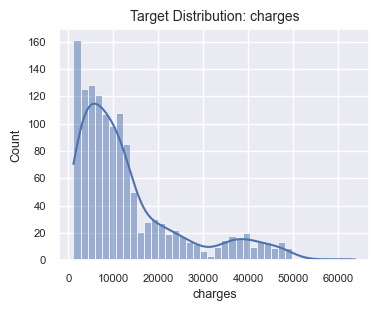

In [16]:
# target column distribution
plt.figure(figsize=(4,3))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title(f"Target Distribution: {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.show()

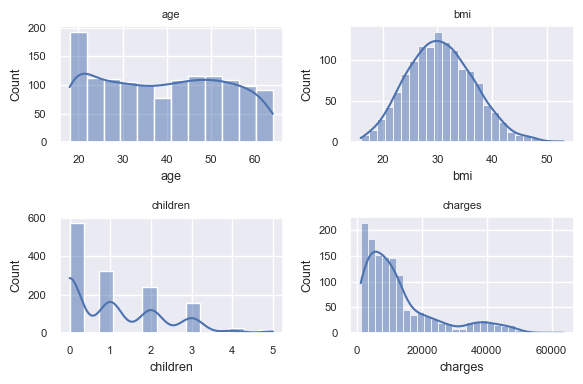

In [17]:
# histogram plot - distribution
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

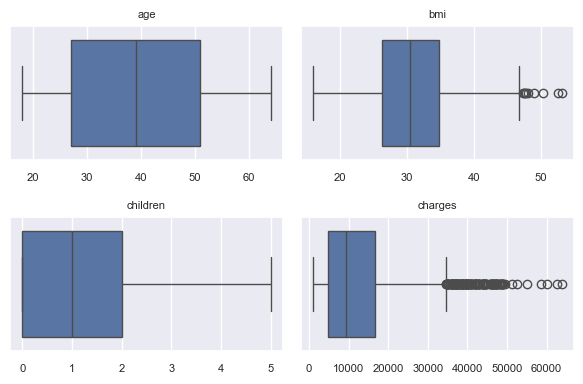

In [18]:
# outliers analysis - boxplot
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

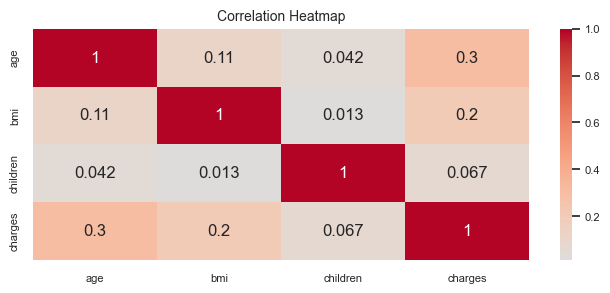

In [19]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 3))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Note: We don't have much correlated columns**

In [20]:
# correlation with target column
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target column:")
print(corr_with_target)

Correlation with target column:
charges    1.000
age        0.298
bmi        0.198
children   0.067
Name: charges, dtype: float64


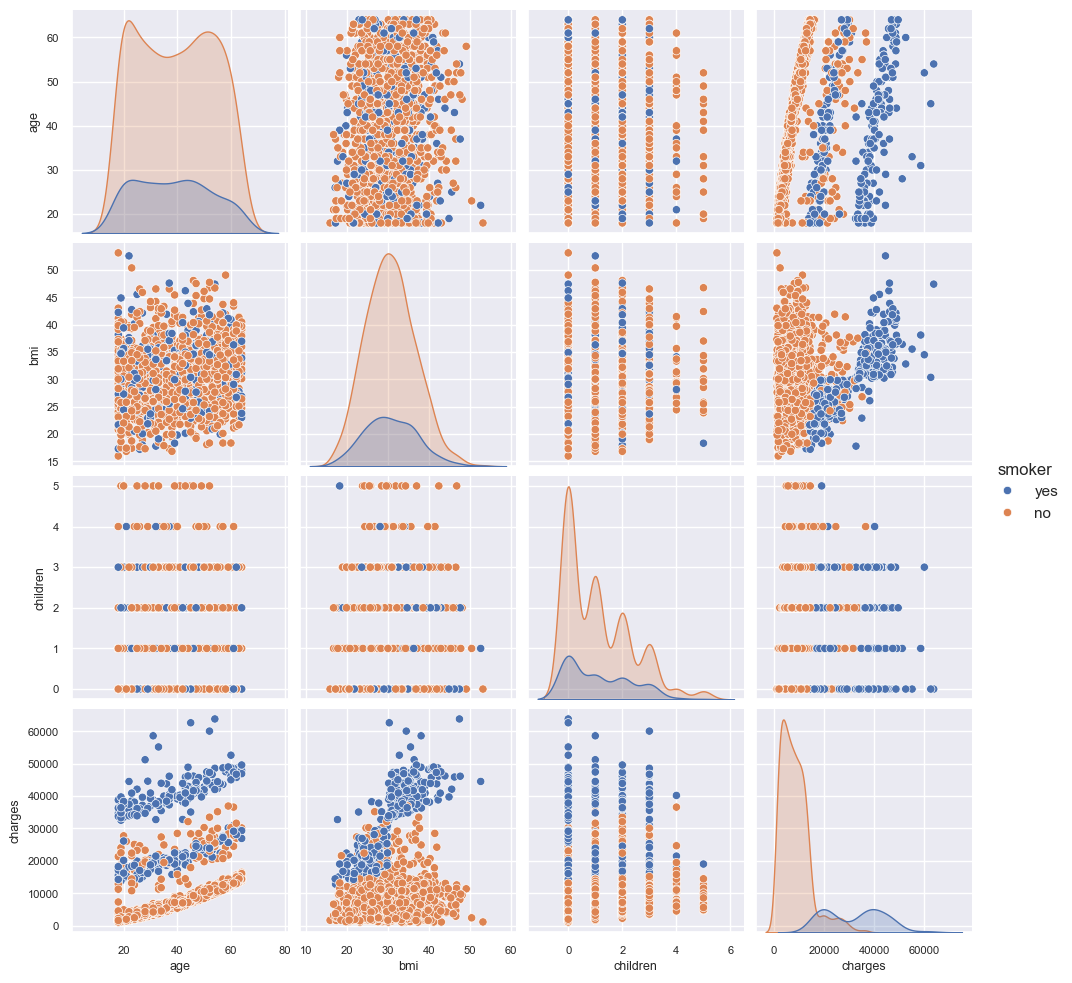

In [21]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()
sns.pairplot(df_pair, hue="smoker", diag_kind="kde")
plt.show()

---

🔍 Key Insights from EDA
- Dataset contains a mix of numerical features (age, bmi, children) and categorical features (sex, smoker, region)
- No missing values detected in any column
- Target variable charges is highly right-skewed with a small number of extreme high-cost outliers
- Smoker status shows a very strong separation in the charges distribution
- Age and BMI show moderate positive correlation with charges
- No severe multicollinearity among numerical features
- Outliers are prominent in charges (and to a lesser extent BMI), especially for smokers

⸻

🛠️ Preprocessing & Evaluation Plan
- No missing value imputation required
- One-hot encode categorical variables (sex, smoker, region)
- Feature scaling applied for linear and regularized models
- No aggressive outlier removal, to preserve real-world high-cost medical cases
- Use pipelines and ColumnTransformer to prevent data leakage
- Baseline model using Linear Regression
- Model comparison using cross-validation
- Tree-based models explored to capture non-linear relationships
- Apply log transformation on the target variable (charges) to handle skewness
- Primary evaluation metric: MAE (robust to extreme outliers)
- Secondary metrics: RMSE and R² (to understand worst-case errors and variance explained)
- Hyperparameter tuning performed only on top-performing models
- Final evaluation conducted strictly on a held-out test set

---

**4. Data Preprocessing**

In [22]:
# separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [23]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [24]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [25]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [26]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1069, 6)
Test set shape: (268, 6)


In [27]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
# imputers can be added in numerical transformer
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


**5. Baseline model (no CV no Tuning)**

In [28]:
basline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [29]:
basline_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


*Evaluation of baseline model*

In [30]:
train_baseline_preds = basline_pipe.predict(X_train)
test_baseline_preds = basline_pipe.predict(X_test)

In [31]:
train_baseline_preds[:5]

array([ 2326.02453297,  3289.2193497 , 14447.83525029, 16820.71016479,
       10116.72986155])

In [33]:
y_train[:5]

1114    2396.096
968     3279.869
599    33471.972
170    13405.390
275     9715.841
Name: charges, dtype: float64

In [34]:
y_test[:5]

900     8688.859
1064    5708.867
1256   11436.738
298    38746.355
237     4463.205
Name: charges, dtype: float64

In [32]:
test_baseline_preds[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

In [36]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_preds)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_preds)
train_baseline_r2 = r2_score(y_train, train_baseline_preds)

print("Training Data metrics:")
print(f"RMSE: {train_baseline_rmse}")
print(f"MAE: {train_baseline_mae}")
print(f"R2: {train_baseline_r2}")

Training Data metrics:
RMSE: 6081.106881541277
MAE: 4181.9015377751475
R2: 0.7299057809339075


In [37]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_preds)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_preds)
test_baseline_r2 = r2_score(y_test, test_baseline_preds)
print("Test Data metrics:")
print(f"RMSE: {test_baseline_rmse}")
print(f"MAE: {test_baseline_mae}")
print(f"R2: {test_baseline_r2}")

Test Data metrics:
RMSE: 5956.3428943635845
MAE: 4177.045561036324
R2: 0.8069287081198014


**6. Model Selection Optimization**

In [40]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor()
}

In [47]:
k = 3
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [48]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [49]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring = scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })
    
# sort based on lowest mae value
cv_results = pd.DataFrame(rows).sort_values("cv_mae")
print("=== CV Model Comparison ===")
print(cv_results)
  

=== CV Model Comparison ===
              model   cv_mae  cv_rmse  cv_r2
4     Random Forest 2756.849 4949.097  0.821
5           XGBoost 3160.259 5385.295  0.788
3      DecisionTree 3367.357 6869.863  0.655
2             Lasso 4218.630 6117.751  0.727
0  LinearRegression 4218.903 6118.028  0.727
1             Ridge 4224.363 6117.847  0.727


In [50]:
best_row = cv_results.sort_values("cv_mae").iloc[0]

best_model_name = best_row["model"]
best_mae = best_row["cv_mae"]

print("Best model based on CV MAE:")
print("Model :", best_model_name)
print("CV MAE:", best_mae)

Best model based on CV MAE:
Model : Random Forest
CV MAE: 2756.848588823759


**Note: Best Model is Random Forest Regressor**

**7. Hyperparamter tuning**

In [51]:
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=1))
    
    ]
)

In [52]:
# hyperparamter combinations to try
param_grid = {
    "model__n_estimators": [200, 300, 600, 900],
    "model__max_depth": [None, 8, 15, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.6, 0.8],
    "model__bootstrap": [True]
}

In [53]:
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

In [54]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 900 out of 900 | elapsed:    2.2s finished


,estimator,Pipeline(step... verbose=1))])
,param_grid,"{'model__bootstrap': [True], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [55]:
print("\n=== TUNED RF (CV) ===")
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED RF (CV) ===
Best CV MAE: 2590.076206722346
Best params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 900}


**8. Retraining with best params**

In [56]:
rf_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=200,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        ))
    ]
)

In [57]:
# train the model with best hyperparameters on the full training data
rf_best.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.3s finished


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
train_final_pred = rf_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Train Performance ===
MAE : 2009.186
RMSE: 3691.493
R2  : 0.900


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.0s finished


In [59]:
test_final_pred = rf_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.1s finished



=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 2379.451
RMSE: 4268.656
R2  : 0.901


*Apply log transformation on target*

In [60]:
rf_best_log = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                bootstrap=True,
                max_depth=8,
                max_features=0.6,
                min_samples_leaf=4,
                min_samples_split=10,
                n_estimators=600,
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

In [61]:
rf_best_log.fit(X_train, y_train)

,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


**9. Final Evaluation**

In [62]:
train_final_pred = rf_best_log.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Train Performance ===
MAE : 1749.331
RMSE: 4068.462
R2  : 0.879


In [63]:
test_final_pred = rf_best_log.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 1959.913
RMSE: 4284.290
R2  : 0.900


In [64]:
test_final_pred = rf_best_log.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 1959.913
RMSE: 4284.290
R2  : 0.900


**10. Building Predictive system**

In [65]:
def predict_insurance_charges(
    model,
    age: float,
    sex: str,
    bmi: float,
    children: int,
    smoker: str,
    region: str
) -> float:

    new_row = pd.DataFrame([{
        "age": age,
        "sex": sex,           # "male" or "female"
        "bmi": bmi,           
        "children": children, 
        "smoker": smoker,     # "yes" or "no"
        "region": region      # "northeast" | "northwest" | "southeast" | "southwest"
    }])

    return float(model.predict(new_row)[0])

In [ ]:
pred = predict_insurance_charges(
    model=rf_best_log,
    age=40,
    sex="male",
    bmi=29.5,
    children=2,
    smoker="no",
    region="southeast"
)

print("Predicted Mediacal Insurance cost", round(pred, 2))

Predicted Mediacal Insurance cost 7546.13
